Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [2]:
json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/"

years = np.arange(1960, 2010, 10) 

files = [f"movies-{y}s.json" for y in years]

file_paths = [json_dir + f for f in files]

print(file_paths)

['https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1960s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1970s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1980s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-1990s.json', 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/movies-2000s.json']


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [3]:
dfs = []

for path in file_paths:
    df = pd.read_json(path)

    df = df.drop(columns=[
        'href', 'extract', 'thumbnail',
        'thumbnail_width', 'thumbnail_height'
    ], errors='ignore')

    df = df.dropna()

    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)

final_df.shape

(10750, 4)

3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [4]:
final_df.head()

,title,year,cast,genres
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]"
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]"
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]"
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]"
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]"


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [5]:
final_df.info

<bound method DataFrame.info of                                      title  year  \
0                            The 3rd Voice  1960   
1                           12 to the Moon  1960   
2                          13 Fighting Men  1960   
3                                13 Ghosts  1960   
4       The Adventures of Huckleberry Finn  1960   
...                                    ...   ...   
10745  The Imaginarium of Doctor Parnassus  2009   
10746                     It's Complicated  2009   
10747                      Sherlock Holmes  2009   
10748       The Loss of a Teardrop Diamond  2009   
10749                     The White Ribbon  2009   

                                                    cast  \
0            [Edmond O'Brien, Laraine Day, Julie London]   
1                                [Ken Clark, Tom Conway]   
2                      [Grant Williams, Carole Matthews]   
3                           [Charles Herbert, Jo Morrow]   
4      [Tony Randall, Patty McCormack, Eddi

5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

In [6]:
genres_exploded = final_df.explode('genres')
top_genres = (
    genres_exploded['genres']
    .value_counts()
    .head(10)
)

print(top_genres)

genres
Comedy             3777
Drama              3758
Action             1228
Thriller           1158
Horror             1044
Romance             948
Crime               873
Science Fiction     708
Adventure           556
Western             492
Name: count, dtype: int64


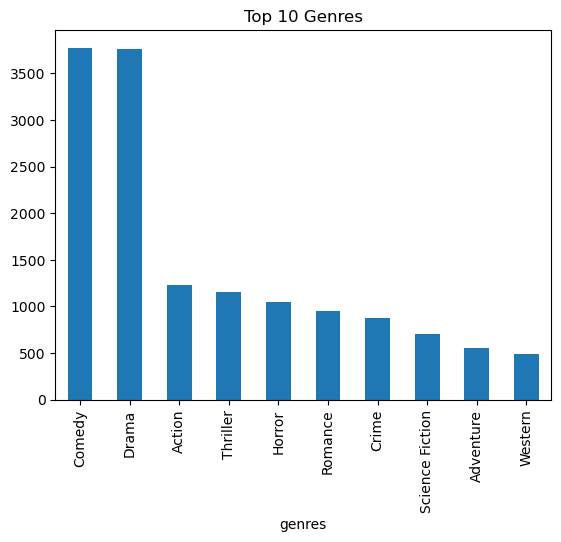

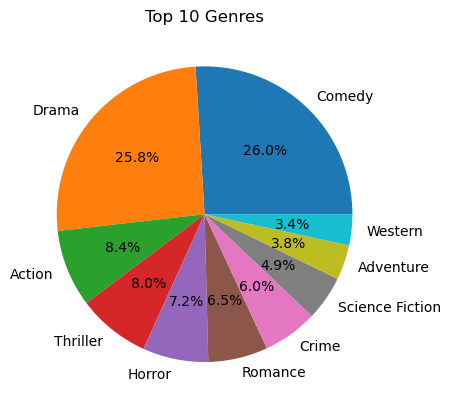

In [7]:
top_genres.plot(kind='bar')
plt.title('Top 10 Genres')
plt.show()

top_genres.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Genres')
plt.ylabel('')
plt.show()

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

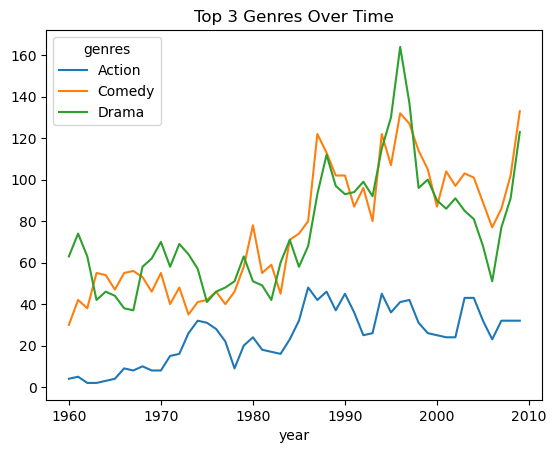

In [8]:
top3_genres = top_genres.head(3).index.tolist()

genre_year = (
    genres_exploded[genres_exploded['genres'].isin(top3_genres)]
    .groupby(['year', 'genres'])
    .size()
    .unstack()
    .fillna(0)
)

genre_year.plot()
plt.title('Top 3 Genres Over Time')
plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

In [9]:
cast_exploded = final_df.explode('cast')
top_actors = (
    cast_exploded['cast']
    .value_counts()
    .head(10)
)

print(top_actors)

cast
Gene Hackman          71
Robert Duvall         68
Robert De Niro        65
Burt Reynolds         63
Harvey Keitel         58
Christopher Walken    57
Donald Sutherland     57
Samuel L. Jackson     55
Michael Caine         54
Jack Nicholson        53
Name: count, dtype: int64


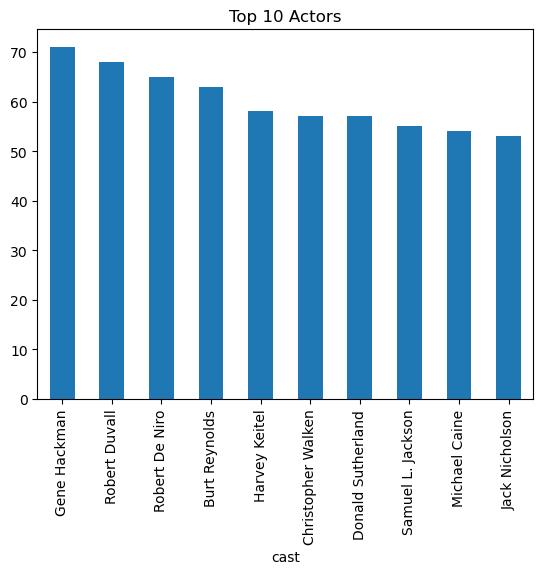

In [10]:
top_actors.plot(kind='bar')
plt.title('Top 10 Actors')
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

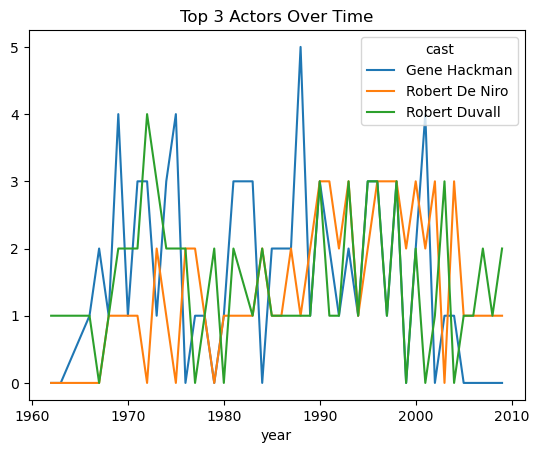

In [11]:
top3_actors = top_actors.head(3).index.tolist()

actor_year = (
    cast_exploded[cast_exploded['cast'].isin(top3_actors)]
    .groupby(['year', 'cast'])
    .size()
    .unstack()
    .fillna(0)
)

actor_year.plot()
plt.title('Top 3 Actors Over Time')
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

In [12]:
genres_exploded['is_top_genre'] = genres_exploded['genres'].isin(top3_genres)
actor_genre = genres_exploded.explode('cast')
top10_actors = top_actors.index.tolist()

actor_stats = (
    actor_genre[actor_genre['cast'].isin(top10_actors)]
    .groupby(['cast', 'is_top_genre'])
    .size()
    .unstack(fill_value=0)
)

actor_stats.columns = ['non_top_genre', 'top_genre']

actor_stats['total'] = actor_stats.sum(axis=1)
actor_stats['top_genre_pct'] = actor_stats['top_genre'] / actor_stats['total'] * 100

print(actor_stats)

                    non_top_genre  top_genre  total  top_genre_pct
cast                                                              
Burt Reynolds                  55         75    130      57.692308
Christopher Walken             66         55    121      45.454545
Donald Sutherland              65         50    115      43.478261
Gene Hackman                   93         59    152      38.815789
Harvey Keitel                  66         55    121      45.454545
Jack Nicholson                 57         48    105      45.714286
Michael Caine                  59         48    107      44.859813
Robert De Niro                 73         66    139      47.482014
Robert Duvall                  66         61    127      48.031496
Samuel L. Jackson              68         43    111      38.738739


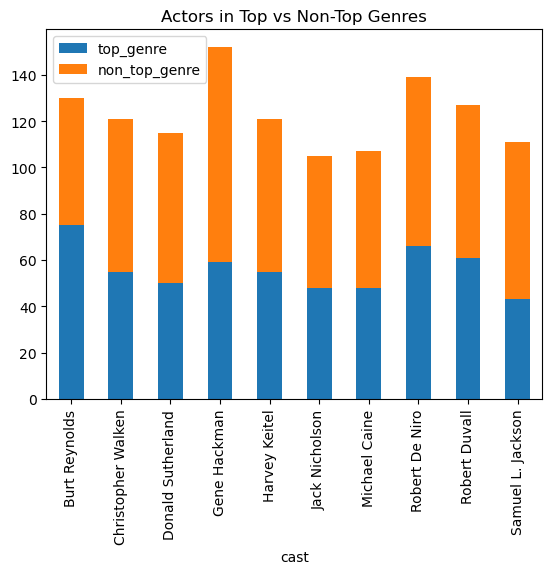

In [13]:
actor_stats[['top_genre', 'non_top_genre']].plot(kind='bar', stacked=True)
plt.title('Actors in Top vs Non-Top Genres')
plt.show()